# Interpretation Workflow

Demonstrates how to probe what a trained sequence-to-function model has learned:
from in silico mutagenesis (ISM) through saliency attribution to motif discovery.

**No GPU or genome files required.** A small synthetic CNN is used in place of a
real foundation model; all patterns transfer directly to a Borzoi fine-tune.

**Workflow covered:**
1. Build a toy sequence model for demonstration
2. ISM with `seq_tools.variant` — score every possible point mutation
3. Visualize ISM as a heatmap with `seq_tools.visualization`
4. The `interpret` subpackage — API tour (grelu-based, shown symbolically)
5. Synthetic saliency / attribution visualization
6. Composite multi-track figure combining all tracks

## 1. Imports and Setup

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt

# Core sequence utilities
from seq_tools.encoding import one_hot_encode
from seq_tools.variant import generate_window_variants

# Visualization module (new in this release)
from seq_tools.visualization import (
    plot_ism_heatmap,
    plot_prediction_track,
    plot_gene_model,
    plot_attribution,
    multi_track_figure,
)

# Check grelu availability for the interpret subpackage
try:
    import grelu
    HAS_GRELU = True
except ImportError:
    HAS_GRELU = False

print(f"NumPy   {np.__version__}")
print(f"PyTorch {torch.__version__}")
print(f"Matplotlib {matplotlib.__version__}")
print(f"grelu   {'available' if HAS_GRELU else 'not installed (interpret subpackage requires grelu[full])'}")

NumPy   1.26.4
PyTorch 2.6.0+cu124
Matplotlib 3.9.2
grelu   available


## 2. Toy Model

We build a small CNN that takes a one-hot encoded sequence `(L, 4)` and produces
a single scalar prediction. In a real workflow this would be a loaded Borzoi
fine-tune.

In [5]:
class ToySeqModel(nn.Module):
    """Minimal 1D-CNN sequence model for demonstration purposes."""

    def __init__(self, in_channels: int = 4, n_filters: int = 32, seq_len: int = 200):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, n_filters, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.Conv1d(n_filters, n_filters, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        self.head = nn.Linear(n_filters, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, L, 4)  →  reshape to (batch, 4, L) for Conv1d
        x = x.permute(0, 2, 1)        # (B, 4, L)
        x = self.conv(x)              # (B, n_filters, L)
        x = x.mean(dim=-1)            # (B, n_filters)
        return self.head(x).squeeze(-1)  # (B,)


torch.manual_seed(42)
SEQ_LEN = 200
model = ToySeqModel(seq_len=SEQ_LEN)
model.eval()

# Synthetic reference sequence
rng = np.random.default_rng(0)
ref_seq = "".join(rng.choice(list("ACGT"), size=SEQ_LEN))
print(f"Reference: {ref_seq[:40]}... ({SEQ_LEN} bp total)")

# One-hot encode
ref_ohe = one_hot_encode(ref_seq)   # (L, 4)
print(f"One-hot shape: {ref_ohe.shape}")

Reference: TGGCCAAAATGTGGTGGGGTCTGACTGATGTAATAGACCC... (200 bp total)
One-hot shape: (200, 4)


## 3. In Silico Mutagenesis (ISM)

ISM asks: *what happens to the model prediction if I change this base to every
other base at every position?*

We use `seq_tools.variant` for this — no grelu required.

In [6]:
# Mutagenize a 60-bp window centered on the sequence
ISM_START, ISM_END = 70, 130

variants = generate_window_variants(ref_seq, start=ISM_START, end=ISM_END)
print(f"Generated {len(variants)} variants across {ISM_END - ISM_START} positions")

# Score all variants against the reference using the toy model directly.
# (seq_tools.variant.score_variants expects a grelu model with predict_on_seqs;
#  here we one-hot encode and call the toy model manually.)
ref_ohe_t = torch.from_numpy(one_hot_encode(ref_seq)[None]).float()   # (1, L, 4)
with torch.no_grad():
    ref_score = float(model(ref_ohe_t).numpy())

all_seqs = [v["sequence"] for v in variants]
all_ohe = np.stack([one_hot_encode(s) for s in all_seqs])              # (N, L, 4)
with torch.no_grad():
    alt_scores_arr = model(torch.from_numpy(all_ohe).float()).numpy()  # (N,)

records = []
for v, alt_val in zip(variants, alt_scores_arr):
    alt_val = float(alt_val)
    log2fc = np.log2(alt_val / ref_score) if ref_score > 0 and alt_val > 0 else 0.0
    records.append({"position": v["position"], "ref": v["ref"], "alt": v["alt"], "log2fc": log2fc})

scores_df = pd.DataFrame(records)
print(f"Scores: min={scores_df['log2fc'].min():.3f}, max={scores_df['log2fc'].max():.3f}")
scores_df.head()

Generated 180 variants across 60 positions
Scores: min=-0.015, max=0.014


/tmp/ipykernel_627326/2293528768.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ref_score = float(model(ref_ohe_t).numpy())


,position,ref,alt,log2fc
0,70,C,A,-0.010441
1,70,C,G,-0.013949
2,70,C,T,-0.009269
3,71,C,A,-0.008494
4,71,C,G,-0.015237


In [7]:
# Reshape scores into a (4, L_window) matrix for visualization
base_order = {"A": 0, "C": 1, "G": 2, "T": 3}
n_pos = ISM_END - ISM_START
ism_matrix = np.zeros((4, n_pos), dtype=float)

for _, row in scores_df.iterrows():
    pos_idx = int(row["position"]) - ISM_START
    alt_idx = base_order[row["alt"]]
    if 0 <= pos_idx < n_pos:
        ism_matrix[alt_idx, pos_idx] = row["log2fc"]

print(f"ISM matrix shape: {ism_matrix.shape}  (ACGT × positions)")
print(f"Value range: [{ism_matrix.min():.3f}, {ism_matrix.max():.3f}]")

ISM matrix shape: (4, 60)  (ACGT × positions)
Value range: [-0.015, 0.014]


### Visualize ISM as a Heatmap

`plot_ism_heatmap` takes the `(4, L)` matrix and renders ACGT rows with a
diverging colormap. Positive values (red) increase the prediction; negative (blue)
decrease it.

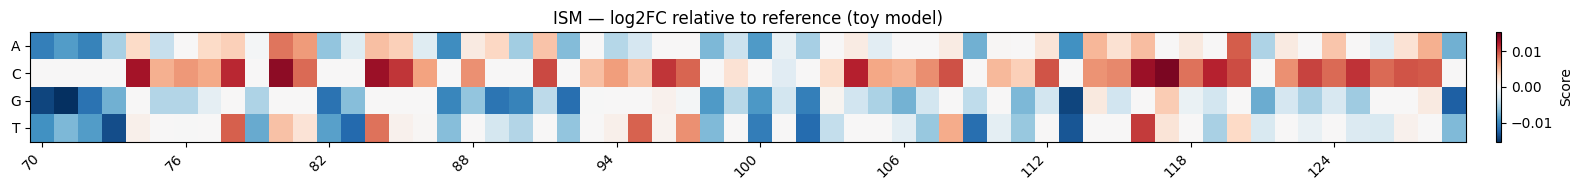

In [8]:
fig, ax = plt.subplots(figsize=(16, 2))
plot_ism_heatmap(
    ism_matrix,
    genome_start=ISM_START,
    ax=ax,
    cmap="RdBu_r",
    title="ISM — log2FC relative to reference (toy model)",
)
plt.tight_layout()
plt.show()

## 4. The `interpret` Subpackage

The `interpret` subpackage provides higher-level wrappers for three interpretation
methods that are tightly integrated with `grelu`:

| Module | What it does | Requires |
|--------|-------------|----------|
| `interpret.ism` | Saturating ISM over arbitrary windows | `grelu` |
| `interpret.attribution` | Gradient-based saliency (DeepLIFT, IG) | `grelu` |
| `interpret.modisco` | TF-MoDISco motif discovery from seqlets | `grelu`, `modiscolite`, `tangermeme` |

When `grelu` is available, the typical workflow is:

In [9]:
# --- API tour (requires grelu) ---
if HAS_GRELU:
    from interpret.ism import run_ism
    from interpret.attribution import get_attributions_for_element
    from interpret.modisco import run_modisco

    # 1. ISM over the full window at model scale
    #    ism_scores shape: (n_tasks, 4, L)
    # ism_scores = run_ism(
    #     model=grelu_model,
    #     seq=ref_ohe,
    #     start=ISM_START,
    #     end=ISM_END,
    #     tasks=[0],
    #     compare_func="log2FC",
    # )

    # 2. Attribution via DeepLIFT or integrated gradients
    #    attribution shape: (L, 4)
    # attribution = get_attributions_for_element(
    #     model=grelu_model,
    #     seq=ref_ohe,
    #     tasks=[0],
    #     bin_start=ISM_START // 32,
    #     bin_end=ISM_END // 32,
    #     method="DeepLIFT",
    # )

    # 3. TF-MoDISco — find recurring sequence patterns in attribution maps
    # run_modisco(
    #     attribution_scores=attribution,       # (L, 4)
    #     one_hot=ref_ohe,                      # (L, 4)
    #     output_dir="modisco_output/",
    # )

    print("grelu is available — uncomment the calls above to run on a real model.")
else:
    print("grelu not installed. Install with:  pip install grelu")
    print("The API calls above show the expected usage pattern.")

grelu is available — uncomment the calls above to run on a real model.


## 5. Attribution Visualization

Attribution maps assign an importance score to each (position, base) pair.
Here we build a synthetic attribution array with embedded high-scoring "motif"
windows to illustrate visualization options.

`plot_attribution` supports two modes:
- **bar** (default): L1 norm across bases, works without additional dependencies
- **logo**: base-stacked information-theoretic logo via `tangermeme` (optional)

In [10]:
# Synthetic attribution: mostly noise with two high-importance windows
rng2 = np.random.default_rng(1)
attribution = rng2.normal(0, 0.05, (SEQ_LEN, 4)).astype(np.float32)

# Embed a "motif" at positions 40-55 (e.g., a 5-prime splice site)
motif_a = rng2.uniform(0.2, 0.6, (15, 4)).astype(np.float32)
attribution[40:55] += motif_a

# And a second motif at positions 140-155
motif_b = rng2.uniform(-0.5, -0.1, (15, 4)).astype(np.float32)
attribution[140:155] += motif_b

# Multiply by one-hot encoding — a common pre-processing step
# that zeros out scores for non-native bases
attribution_native = attribution * ref_ohe   # (L, 4)

print(f"Attribution shape: {attribution_native.shape}")
print(f"Value range: [{attribution_native.min():.3f}, {attribution_native.max():.3f}]")

Attribution shape: (200, 4)
Value range: [-0.519, 0.468]


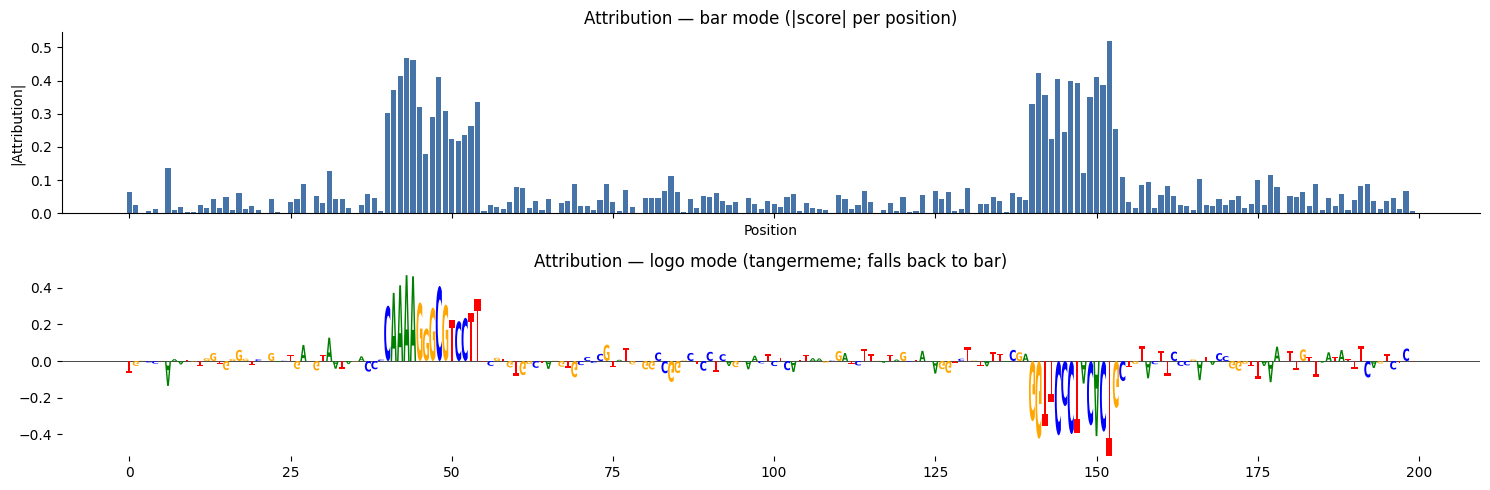

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

# Bar mode (always available)
plot_attribution(
    attribution_native,
    ax=axes[0],
    mode="bar",
    title="Attribution — bar mode (|score| per position)",
)

# Logo mode (requires tangermeme; falls back to bar if not installed)
plot_attribution(
    attribution_native,
    ax=axes[1],
    mode="logo",
    title="Attribution — logo mode (tangermeme; falls back to bar)",
)

plt.tight_layout()
plt.show()

## 6. Synthetic Soft Labels and Gene Model Track

In practice, `generate_soft_labels` produces segment DataFrames from rMATS + StringTie.
Here we build one directly to demonstrate the gene model visualization.

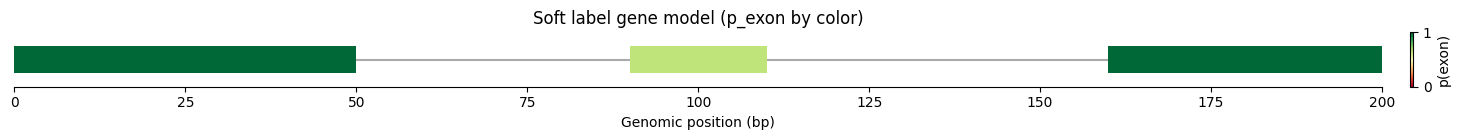

In [12]:
import pandas as pd

# Synthetic soft label DataFrame (as if from generate_soft_labels)
labels = pd.DataFrame([
    {"Start": 0,   "End": 50,  "p_exon": 1.0, "confidence": 8.0, "Strand": "+"},
    {"Start": 50,  "End": 90,  "p_exon": 0.0, "confidence": 0.0, "Strand": "+"},  # intron
    {"Start": 90,  "End": 110, "p_exon": 0.65, "confidence": 4.2, "Strand": "+"},  # PSI=0.65
    {"Start": 110, "End": 160, "p_exon": 0.0, "confidence": 0.0, "Strand": "+"},  # intron
    {"Start": 160, "End": 200, "p_exon": 1.0, "confidence": 9.1, "Strand": "+"},
])

fig, ax = plt.subplots(figsize=(15, 1.5))
plot_gene_model(
    labels,
    ax=ax,
    title="Soft label gene model (p_exon by color)",
)
plt.tight_layout()
plt.show()

## 7. Composite Multi-Track Figure

`multi_track_figure` creates a stacked, shared-x-axis layout — the standard
presentation for genomic deep learning results. Combine ISM, attribution, a
model prediction, and a gene model into a single publication-ready figure.

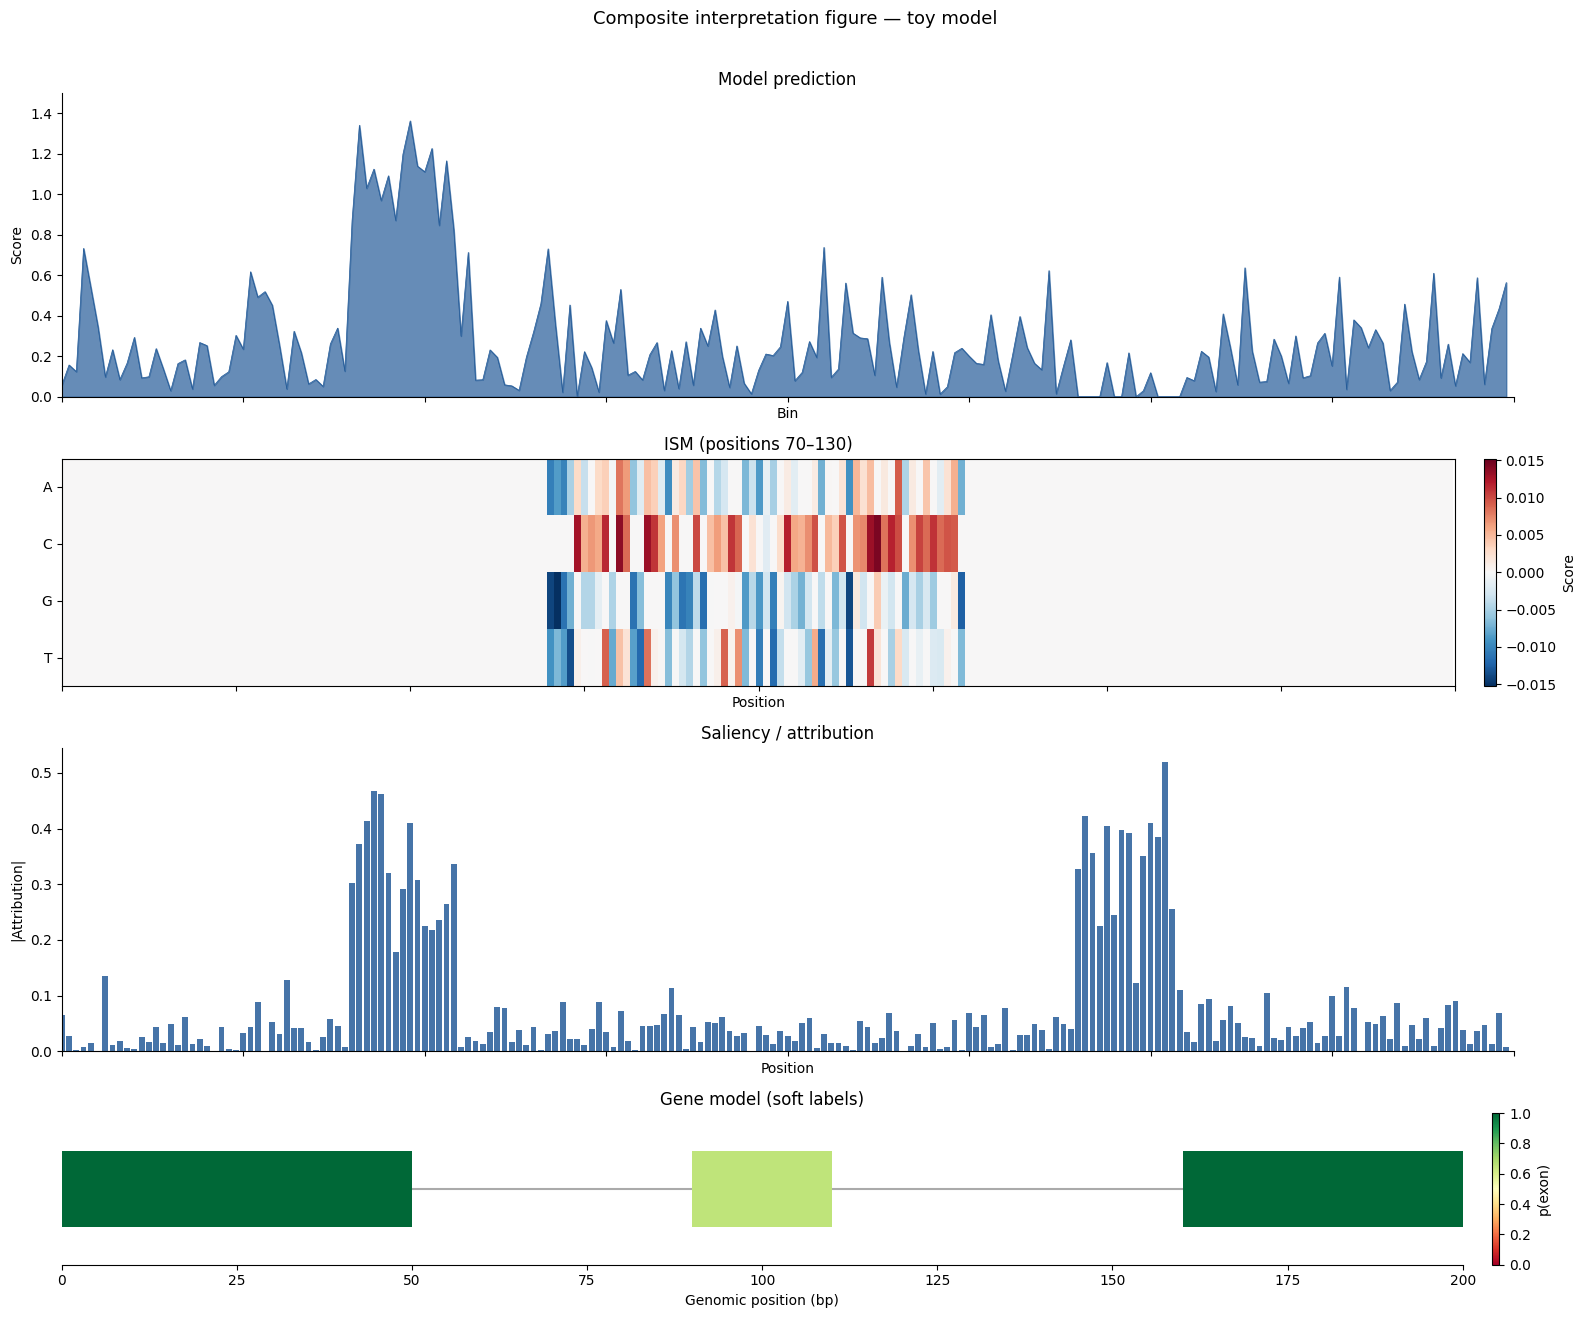

In [13]:
# Synthetic model prediction track
rng3 = np.random.default_rng(2)
pred_track = np.abs(rng3.normal(0, 0.3, SEQ_LEN)).astype(np.float32)
pred_track[40:55] += 0.8   # elevated around motif A
pred_track[140:155] -= 0.3
pred_track = np.clip(pred_track, 0, None)

# Multi-track: prediction | ISM (padded) | attribution | gene model
# ISM only covers positions 70-130; pad full-length for alignment
ism_full = np.zeros((4, SEQ_LEN))
ism_full[:, ISM_START:ISM_END] = ism_matrix

fig, axes = multi_track_figure(
    n_tracks=4,
    height_ratios=[2, 1.5, 2, 1],
    figsize=(16, None),
    track_height=2.0,
)

plot_prediction_track(
    pred_track,
    ax=axes[0],
    color="#255C99",
    title="Model prediction",
    ylabel="Score",
)

plot_ism_heatmap(
    ism_full,
    ax=axes[1],
    cmap="RdBu_r",
    title="ISM (positions 70–130)",
)

plot_attribution(
    attribution_native,
    ax=axes[2],
    mode="bar",
    title="Saliency / attribution",
)

plot_gene_model(
    labels,
    ax=axes[3],
    title="Gene model (soft labels)",
    use_psi_color=True,
)

fig.suptitle("Composite interpretation figure — toy model", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Seqlet-to-Motif Workflow (Conceptual)

Once attribution maps exist from a real model, the motif discovery pipeline is:

```
attribution maps (L, 4)  →  run_modisco()  →  seqlets (recurring patterns)
    →  TOMTOM alignment  →  known motif database matches
    →  FIMO enrichment   →  which events are driven by which motifs
```

The `interpret.modisco` module wraps `modiscolite` and `tangermeme`:

```python
from interpret.modisco import run_modisco

# attribution_stack: (n_seqs, L, 4)  —  one map per training window
# ohe_stack:         (n_seqs, L, 4)
run_modisco(
    attribution_scores=attribution_stack,
    one_hot=ohe_stack,
    output_dir="modisco_output/",
    window=20,
    max_seqlets=50_000,
)
# Produces:  modisco_output/modisco.h5  (viewable with modisco-lite's report tool)
#            modisco_output/tomtom/     (if motif DB provided)
```

See `interpret/modisco.py` for the full parameter list.

---

## Summary

| Step | Tool | grelu needed? |
|------|------|---------------|
| Saturating ISM (small windows) | `seq_tools.variant.score_variants` | No |
| ISM at model scale | `interpret.ism.run_ism` | Yes |
| Gradient attribution | `interpret.attribution.get_attributions_for_element` | Yes |
| Motif discovery | `interpret.modisco.run_modisco` | Yes + modiscolite |
| ISM heatmap | `seq_tools.visualization.plot_ism_heatmap` | No |
| Attribution plot | `seq_tools.visualization.plot_attribution` | No (logo mode: tangermeme) |
| Gene model track | `seq_tools.visualization.plot_gene_model` | No |
| Composite figure | `seq_tools.visualization.multi_track_figure` | No |